In [1]:
from pyfiglet import Figlet 
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore") # for avoid warning messages

In [2]:
# title :)
f = Figlet(font = 'slant')
print(f.renderText("S6 app"))

   _____ _____                    
  / ___// ___/   ____ _____  ____ 
  \__ \/ __ \   / __ `/ __ \/ __ \
 ___/ / /_/ /  / /_/ / /_/ / /_/ /
/____/\____/   \__,_/ .___/ .___/ 
                   /_/   /_/      



In [3]:
# load json data
df = pd.read_json("data/s6.json")
df

,data_base_advanced,numerical_methods,cyber_security,data_security,data_analysis_advanced,advanced_web_programming,Machine_learning_1
coef,3,3,1,3,3,3,4
td,0,0,-1,-1,0,-1,-1
tp,0,0,-1,0,0,0,0
exman,0,0,0,0,0,0,0
level,hard,medium,easy,medium,hard,medium,hard
field,software engineering,software engineering,Cybersecurity,Cybersecurity,Data Science,software engineering,Data Science


In [4]:
# transpose data (col ==> row and row ==> col) => for easy processing
df_trans = df.T
df_trans

,coef,td,tp,exman,level,field
data_base_advanced,3,0,0,0,hard,software engineering
numerical_methods,3,0,0,0,medium,software engineering
cyber_security,1,-1,-1,0,easy,Cybersecurity
data_security,3,-1,0,0,medium,Cybersecurity
data_analysis_advanced,3,0,0,0,hard,Data Science
advanced_web_programming,3,-1,0,0,medium,software engineering
Machine_learning_1,4,-1,0,0,hard,Data Science


In [5]:
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, data_base_advanced to Machine_learning_1
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   coef    7 non-null      object
 1   td      7 non-null      object
 2   tp      7 non-null      object
 3   exman   7 non-null      object
 4   level   7 non-null      object
 5   field   7 non-null      object
dtypes: object(6)
memory usage: 692.0+ bytes


In [6]:
# verify
df_trans.dtypes

coef     object
td       object
tp       object
exman    object
level    object
field    object
dtype: object

In [7]:
print(f"dims (row , col) <==> {df.shape}")

dims (row , col) <==> (6, 7)


In [8]:
names = df.columns.tolist()
names

['data_base_advanced',
 'numerical_methods',
 'cyber_security',
 'data_security',
 'data_analysis_advanced',
 'advanced_web_programming',
 'Machine_learning_1']

In [11]:
# get copy of df (immutable)
modules = df_trans.copy()

In [12]:
#### # get (td , tp , exman) inputs from user
def enterModules():

    # for avoid enter in forbidden cells
    def edit(name, typ):
        if modules.loc[name , typ] ==-1:
            return
        td_or_tp =input(f"{typ} : ")
        while validation(td_or_tp) == False:
                 td_or_tp =input(f"{typ} : ")
        modules.loc[name , typ] = td_or_tp 

    

    # validation
    def validation(value):
        if value == "exit":
            return -1
        # verify number 
        try :
            value =float(value)
            # verify range
            if value < 0 or value > 20:
                print(f'{value} out of range  ....')
                return False
            else:
                return True
        except ValueError:
            print(f'{value} is not number  ....')
            return False

    
    for name in names:
             print(f"module {name} : ")
             
             exman =input("exman : ");
             while validation(exman) == False:
                 exman =input("exman : ")
             # for exit 
             if validation(exman) == -1:
                 return
             modules.loc[name , 'exman'] =exman;
             edit(name, "td")
             edit(name , "tp")


    print(modules)

enterModules()

module data_base_advanced : 


exman :  10
td :  19
tp :  19


module numerical_methods : 


exman :  18
td :  14
tp :  13


module cyber_security : 


...

module advanced_web_programming : 


exman :  10
tp :  17


module Machine_learning_1 : 


exman :  13
tp :  15


                         coef  td  tp exman   level                 field
data_base_advanced          3  19  19    10    hard  software engineering
numerical_methods           3  14  13    18  medium  software engineering
cyber_security              1  -1  -1    10    easy         Cybersecurity
data_security               3  -1  20    10  medium         Cybersecurity
data_analysis_advanced      3  12  19    19    hard          Data Science
advanced_web_programming    3  -1  17    10  medium  software engineering
Machine_learning_1          4  -1  15    13    hard          Data Science


In [13]:
# update
modules

,coef,td,tp,exman,level,field
data_base_advanced,3,19,19,10,hard,software engineering
numerical_methods,3,14,13,18,medium,software engineering
cyber_security,1,-1,-1,10,easy,Cybersecurity
data_security,3,-1,20,10,medium,Cybersecurity
data_analysis_advanced,3,12,19,19,hard,Data Science
advanced_web_programming,3,-1,17,10,medium,software engineering
Machine_learning_1,4,-1,15,13,hard,Data Science


In [14]:
modules.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, data_base_advanced to Machine_learning_1
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   coef    7 non-null      object
 1   td      7 non-null      object
 2   tp      7 non-null      object
 3   exman   7 non-null      object
 4   level   7 non-null      object
 5   field   7 non-null      object
dtypes: object(6)
memory usage: 692.0+ bytes


In [15]:
# convert datatype 
modules[["td" , "tp","exman"]] = modules[["td" , "tp" , "exman"]].astype(float)
modules["coef"] = modules["coef"].astype(int)

In [16]:
modules.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, data_base_advanced to Machine_learning_1
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   coef    7 non-null      int64  
 1   td      7 non-null      float64
 2   tp      7 non-null      float64
 3   exman   7 non-null      float64
 4   level   7 non-null      object 
 5   field   7 non-null      object 
dtypes: float64(3), int64(1), object(2)
memory usage: 692.0+ bytes


In [17]:
list_averages = []
def calcAverage():
    global list_averages
    sum_average = 0
    sum_ = 0
    average = 0
    for name in names:
         print("====================================")
         print(f"module {name} : ")
         if modules.loc[name]["td"] ==-1 and modules.loc[name]["tp"] ==-1:
             
             sum_ = average = modules.loc[name]["exman"]*modules.loc[name]["coef"];
         elif modules.loc[name]["td"] ==-1:
             average =  modules.loc[name]["tp"]*0.4 + modules.loc[name]["exman"]*0.6
             sum_ = average*modules.loc[name]["coef"] ;
         elif modules.loc[name]["tp"] ==-1:
             average =   modules.loc[name]["td"]*0.4 + modules.loc[name]["exman"]*0.6
             sum_ = average*modules.loc[name]["coef"] ;
         else:
             average =  modules.loc[name]["td"]*0.2+modules.loc[name]["tp"]*0.2 + modules.loc[name]["exman"]*0.6
             sum_ = average*modules.loc[name]["coef"] ;
             
         print(f"avearge : {average:.2f} ")
         sum_average +=sum_
         list_averages.append(average)
    
    general_average = sum_average / 20;
    print("________________________________________")
    print(f" GENERAL AVERAGE : {general_average:.2f}" )
    print("________________________________________")
calcAverage()

module data_base_advanced : 
avearge : 13.60 
module numerical_methods : 
avearge : 16.20 
module cyber_security : 
avearge : 10.00 
module data_security : 
avearge : 14.00 
module data_analysis_advanced : 
avearge : 17.60 
module advanced_web_programming : 
avearge : 12.80 
module Machine_learning_1 : 
avearge : 13.80 
________________________________________
 GENERAL AVERAGE : 14.39
________________________________________


In [18]:
names_only_td = list(modules[modules['td'] != -1].index.values)

In [19]:
modules['td'].loc[names_only_td].describe()

count     3.000000
mean     15.000000
std       3.605551
min      12.000000
25%      13.000000
50%      14.000000
75%      16.500000
max      19.000000
Name: td, dtype: float64

In [20]:
names_only_tp = list(modules[modules['tp'] != -1].index.values)
names_only_tp

['data_base_advanced',
 'numerical_methods',
 'data_security',
 'data_analysis_advanced',
 'advanced_web_programming',
 'Machine_learning_1']

In [21]:
modules["tp"].loc[names_only_tp].describe()

count     6.000000
mean     17.166667
std       2.714160
min      13.000000
25%      15.500000
50%      18.000000
75%      19.000000
max      20.000000
Name: tp, dtype: float64

In [22]:
modules["exman"].describe()

count     7.000000
mean     12.857143
std       4.017817
min      10.000000
25%      10.000000
50%      10.000000
75%      15.500000
max      19.000000
Name: exman, dtype: float64

In [23]:
modules["average"] = list_averages
modules

,coef,td,tp,exman,level,field,average
data_base_advanced,3,19.0,19.0,10.0,hard,software engineering,13.6
numerical_methods,3,14.0,13.0,18.0,medium,software engineering,16.2
cyber_security,1,-1.0,-1.0,10.0,easy,Cybersecurity,10.0
data_security,3,-1.0,20.0,10.0,medium,Cybersecurity,14.0
data_analysis_advanced,3,12.0,19.0,19.0,hard,Data Science,17.6
advanced_web_programming,3,-1.0,17.0,10.0,medium,software engineering,12.8
Machine_learning_1,4,-1.0,15.0,13.0,hard,Data Science,13.8


In [24]:
modules["sum"] = modules["coef"]*modules["average"]

In [25]:
modules

,coef,td,tp,exman,level,field,average,sum
data_base_advanced,3,19.0,19.0,10.0,hard,software engineering,13.6,40.8
numerical_methods,3,14.0,13.0,18.0,medium,software engineering,16.2,48.6
cyber_security,1,-1.0,-1.0,10.0,easy,Cybersecurity,10.0,10.0
data_security,3,-1.0,20.0,10.0,medium,Cybersecurity,14.0,42.0
data_analysis_advanced,3,12.0,19.0,19.0,hard,Data Science,17.6,52.8
advanced_web_programming,3,-1.0,17.0,10.0,medium,software engineering,12.8,38.4
Machine_learning_1,4,-1.0,15.0,13.0,hard,Data Science,13.8,55.2


In [26]:
df.columns

Index(['data_base_advanced', 'numerical_methods', 'cyber_security',
       'data_security', 'data_analysis_advanced', 'advanced_web_programming',
       'Machine_learning_1'],
      dtype='object')

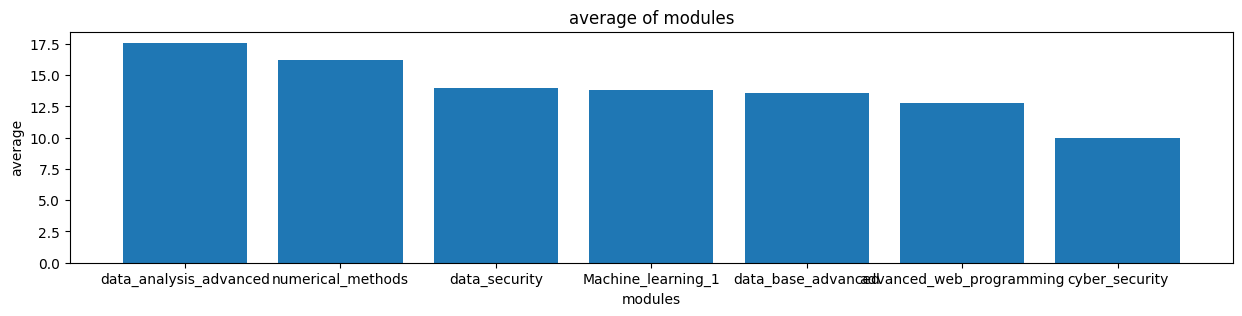

In [27]:
# distribution of averages
average_modules = pd.DataFrame({
     "name" : modules.index,
     "average" : modules["average"]
}).sort_values(by = "average"  , ascending = False)

average_modules

plt.figure(figsize=(15,3))
plt.bar(x= average_modules["name"] , height=average_modules["average"])
plt.title("average of modules")
plt.ylabel("average")
plt.xlabel("modules")
plt.show()

In [28]:
modules["level"].value_counts()

level
hard      3
medium    3
easy      1
Name: count, dtype: int64

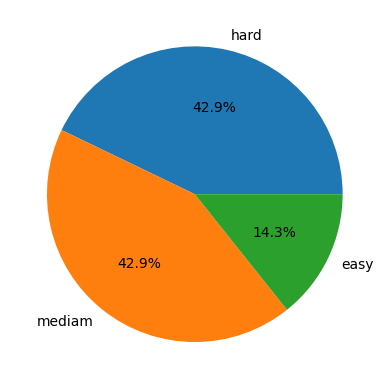

In [29]:
# distributiion level of all module
levels = modules["level"].value_counts()
plt.pie(levels.values , labels = ["hard" , "mediam" ,"easy"],autopct = "%1.1f%%" )
plt.show()

In [30]:
# max value
levels.max()

np.int64(3)

In [31]:
# name of max value
levels.idxmax() 

'hard'

- the most module is hard

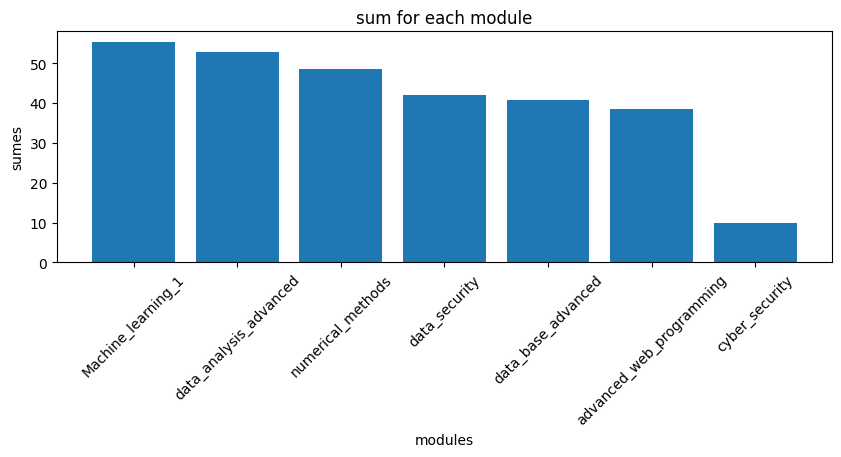

In [32]:
# find modules (cause in increase average  or  decrease average) qccordinf sum

sum_modules = pd.DataFrame({
     "name" : modules.index,
     "sum" : modules["sum"]
}).sort_values(by = "sum"  , ascending = False)

sum_modules

plt.figure(figsize=(10,3))
plt.bar(x= sum_modules["name"] , height=sum_modules["sum"])
plt.title("sum for each module")
plt.ylabel("sumes")
plt.xlabel("modules")
plt.xticks(rotation = 45)
plt.show()

In [33]:
average_level = modules.groupby("level")["average"].sum()

# What level of modules did you achieve the highest grades in, according to your average?

In [34]:
average_level

level
easy      10.0
hard      45.0
medium    43.0
Name: average, dtype: float64

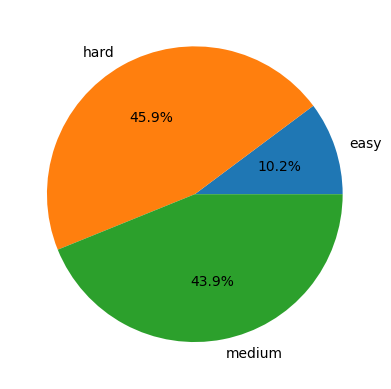

In [35]:

plt.pie(average_level.values , labels = average_level.index,autopct = "%1.1f%%" )
plt.show()

In [36]:
sum_level = modules.groupby("level")["sum"].sum()

In [37]:
sum_level

level
easy       10.0
hard      148.8
medium    129.0
Name: sum, dtype: float64

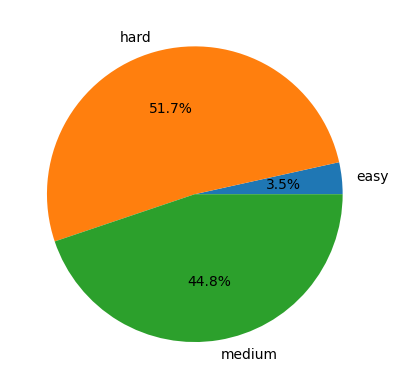

In [38]:

plt.pie(sum_level.values , labels = sum_level.index,autopct = "%1.1f%%" )
plt.show()

In [39]:
field_average = modules.groupby("field")["average"].sum()

In [40]:
field_average

field
Cybersecurity           24.0
Data Science            31.4
software engineering    42.6
Name: average, dtype: float64

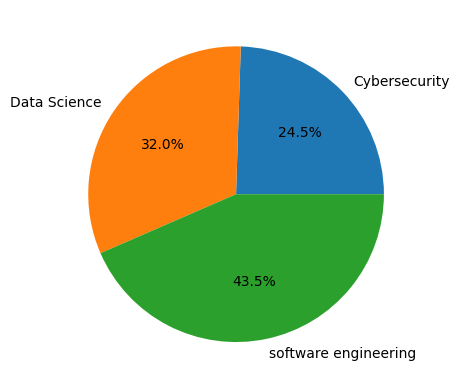

In [41]:

plt.pie(field_average.values , labels = field_average.index,autopct = "%1.1f%%" )
plt.show()

In [42]:
field_sum = modules.groupby("field")["sum"].sum()

In [43]:
field_sum 

field
Cybersecurity            52.0
Data Science            108.0
software engineering    127.8
Name: sum, dtype: float64

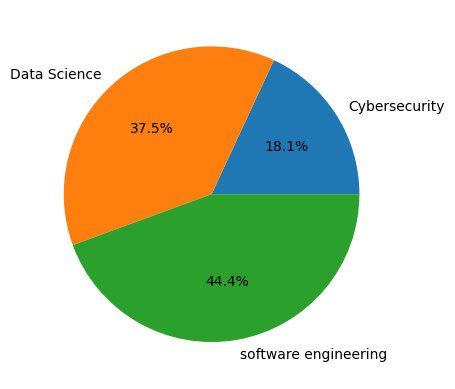

In [44]:

plt.pie(field_sum.values , labels = field_sum.index,autopct = "%1.1f%%" )
plt.show()

In [45]:
modules['td'].loc[names_only_td]

data_base_advanced        19.0
numerical_methods         14.0
data_analysis_advanced    12.0
Name: td, dtype: float64

### distribution of tds , tps , exmans  

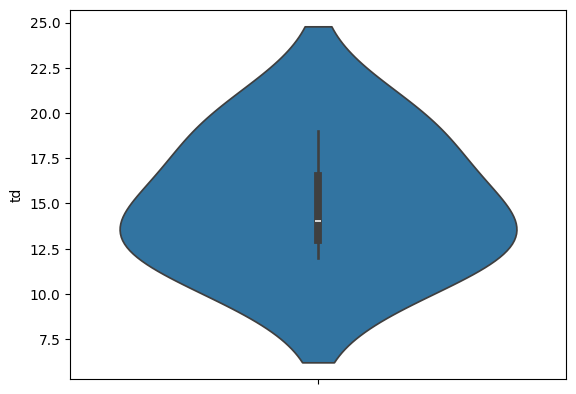

In [46]:
sns.violinplot(modules['td'].loc[names_only_td])
plt.show()

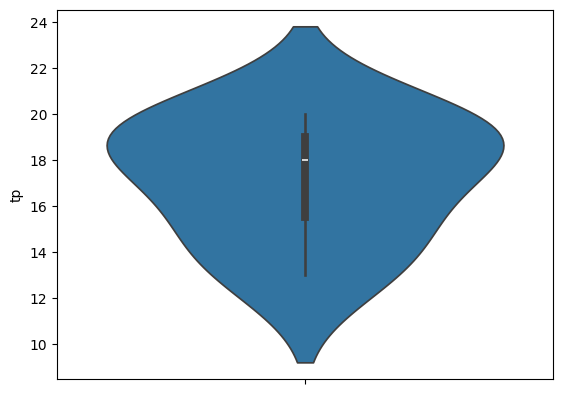

In [47]:
sns.violinplot(modules['tp'].loc[names_only_tp])
plt.show()

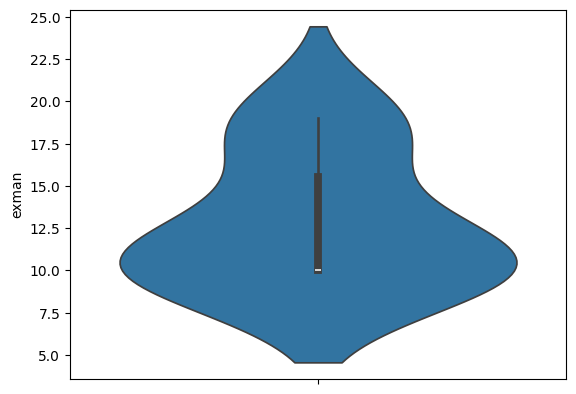

In [48]:
sns.violinplot(modules["exman"])
plt.show()

In [50]:
modules.to_csv("myData.csv" , index = False)